✅ डेटा यशस्वीरित्या तयार झाला!


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


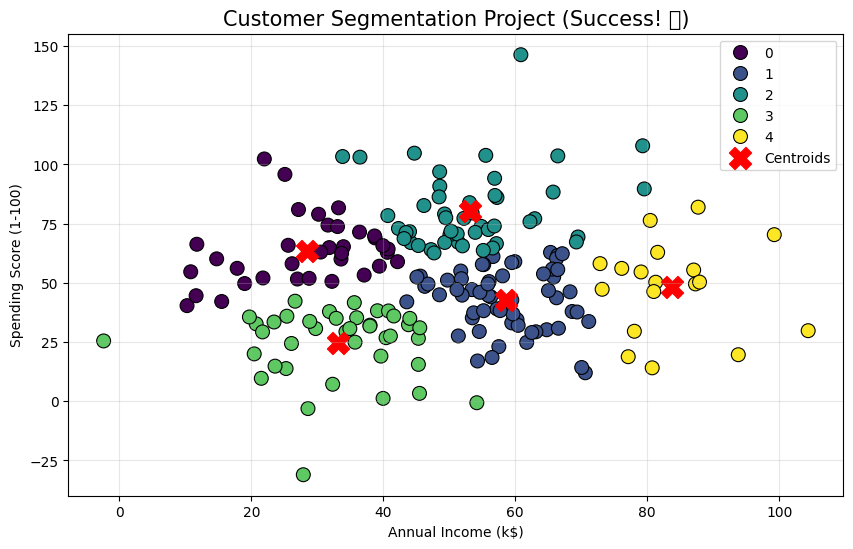

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# १. स्वतःचा डेटा तयार करणे (जेणेकरून 404 Error येणार नाही)
np.random.seed(42)
data_size = 200

# वार्षिक उत्पन्न (Income) आणि खर्चाचा स्कोअर (Spending Score) तयार करणे
income = np.random.normal(50, 20, data_size)
spending = np.random.normal(50, 25, data_size)

df = pd.DataFrame({
    'CustomerID': range(1, data_size + 1),
    'Annual Income (k$)': income,
    'Spending Score (1-100)': spending
})

print("✅ डेटा यशस्वीरित्या तयार झाला!")

# २. क्लस्टरिंगसाठी डेटा निवडणे
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# ३. स्केलिंग (Scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ४. K-Means क्लस्टरिंग (५ ग्रुप्स)
model = KMeans(n_clusters=5, n_init=10, random_state=42)
df['Cluster'] = model.fit_predict(X_scaled)

# ५. रिझल्ट व्हिज्युअलायझेशन (Graph)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Cluster', data=df, palette='viridis', s=100, edgecolor='black')

# क्लस्टरचे सेंटर्स (Centroids) दाखवणे
centers = scaler.inverse_transform(model.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=250, marker='X', label='Centroids')

plt.title("Customer Segmentation Project (Success! ✅)", fontsize=15)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

